In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Input, 
                                     Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm import tqdm
import logging

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.10.1


In [2]:
DATA_DIR = "Data/"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

# Konfigurasi Looping
N_ITERATIONS = 5
TEST_SIZE = 0.15  # 10% untuk test set (locked)
SAMPLING_SIZE = 0.75  # 80% sampling per iterasi dari train+val pool

# Konfigurasi Training
PHASE1_MAX_EPOCHS = 15
PHASE1_PATIENCE = 3
PHASE2_MAX_EPOCHS = 35
PHASE2_PATIENCE = 5
TUNING_EPOCHS = 5

# Konfigurasi Hyperparameter Tuning
HYPERPARAMETER_SPACE = {
    'learning_rate': [0.001, 0.01],
    'batch_size': [16, 32],
    'dropout_rate': [0.2, 0.3, 0.5]
}

TUNING_CONFIG = {
    'grid_search': 12,  # Total kombinasi
    'random_search': 6,  # trials
    'bayesian_optimization': 6,  # trials
    'pso': {
        'n_particles': 4,
        'n_iterations': 4
    }
}

OPTIMIZERS = ['Adam', 'SGD', 'RMSprop', 'Adagrad']
TUNING_METHODS = ['Grid Search', 'Random Search', 'Bayesian Optimization', 'PSO']

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('training_log.txt'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logger.info(f"✓ GPU terdeteksi: {len(gpus)} device(s)")
    except RuntimeError as e:
        logger.warning(f"⚠ GPU Error: {e}")
else:
    logger.warning("⚠ GPU tidak terdeteksi, menggunakan CPU")

print(f"\n📋 KONFIGURASI:")
print(f"  • Iterasi: {N_ITERATIONS}")
print(f"  • Test Set: {TEST_SIZE*100:.0f}% (locked)")
print(f"  • Sampling per iterasi: {SAMPLING_SIZE*100:.0f}%")
print(f"  • Optimizer: {len(OPTIMIZERS)}")
print(f"  • Tuning Methods: {len(TUNING_METHODS)}")
print(f"  • Total Eksperimen: {N_ITERATIONS} × {len(OPTIMIZERS)} × {len(TUNING_METHODS)} = {N_ITERATIONS * len(OPTIMIZERS) * len(TUNING_METHODS)}")
print(f"\n  Hyperparameter Tuning Config:")
print(f"  • Grid Search: {TUNING_CONFIG['grid_search']} kombinasi")
print(f"  • Random Search: {TUNING_CONFIG['random_search']} trials")
print(f"  • Bayesian Opt: {TUNING_CONFIG['bayesian_optimization']} trials")
print(f"  • PSO: {TUNING_CONFIG['pso']['n_particles']} particles × {TUNING_CONFIG['pso']['n_iterations']} iterations")

2026-01-13 17:05:51,975 - INFO - ✓ GPU terdeteksi: 1 device(s)



📋 KONFIGURASI:
  • Iterasi: 5
  • Test Set: 15% (locked)
  • Sampling per iterasi: 75%
  • Optimizer: 4
  • Tuning Methods: 4
  • Total Eksperimen: 5 × 4 × 4 = 80

  Hyperparameter Tuning Config:
  • Grid Search: 12 kombinasi
  • Random Search: 6 trials
  • Bayesian Opt: 6 trials
  • PSO: 4 particles × 4 iterations


In [3]:
def load_dataset(data_dir):
    """Load dataset 13 kelas batik"""
    image_paths = []
    labels = []
    
    # Expected classes
    expected_classes = [
        'Betawi', 'Bokorkencor', 'Buketan', 'Dayak', 'Jlamprang',
        'Kawung', 'Liong', 'Megamendung', 'Parang', 'Sekarjagad',
        'Sidoluhur', 'Sidomukti', 'Singobarong'
    ]
    
    detected_classes = sorted([d for d in os.listdir(data_dir) 
                              if os.path.isdir(os.path.join(data_dir, d))])
    
    logger.info(f"Kelas terdeteksi: {detected_classes}")
    
    class_distribution = {}
    
    for idx, class_name in enumerate(detected_classes):
        class_path = os.path.join(data_dir, class_name)
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        class_distribution[class_name] = len(images)
        logger.info(f"  • {class_name}: {len(images)} gambar")
        
        for img_name in images:
            image_paths.append(os.path.join(class_path, img_name))
            labels.append(idx)
    
    return np.array(image_paths), np.array(labels), detected_classes, class_distribution

all_paths, all_labels, CLASS_NAMES, class_dist = load_dataset(DATA_DIR)
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n✓ Total gambar: {len(all_paths)}")
print(f"✓ Jumlah kelas: {NUM_CLASSES}")
print(f"✓ Kelas: {CLASS_NAMES}")

2026-01-13 17:05:51,995 - INFO - Kelas terdeteksi: ['Betawi', 'Bokorkencor', 'Buketan', 'Dayak', 'Jlamprang', 'Kawung', 'Liong', 'Megamendung', 'Parang', 'Sekarjagad', 'Sidoluhur', 'Sidomukti', 'Singobarong']
2026-01-13 17:05:51,995 - INFO -   • Betawi: 60 gambar
2026-01-13 17:05:51,995 - INFO -   • Bokorkencor: 60 gambar
2026-01-13 17:05:51,995 - INFO -   • Buketan: 60 gambar
2026-01-13 17:05:52,006 - INFO -   • Dayak: 57 gambar
2026-01-13 17:05:52,006 - INFO -   • Jlamprang: 60 gambar
2026-01-13 17:05:52,006 - INFO -   • Kawung: 638 gambar
2026-01-13 17:05:52,006 - INFO -   • Liong: 60 gambar
2026-01-13 17:05:52,006 - INFO -   • Megamendung: 602 gambar
2026-01-13 17:05:52,016 - INFO -   • Parang: 634 gambar
2026-01-13 17:05:52,016 - INFO -   • Sekarjagad: 57 gambar
2026-01-13 17:05:52,016 - INFO -   • Sidoluhur: 57 gambar
2026-01-13 17:05:52,016 - INFO -   • Sidomukti: 57 gambar
2026-01-13 17:05:52,016 - INFO -   • Singobarong: 60 gambar



✓ Total gambar: 2462
✓ Jumlah kelas: 13
✓ Kelas: ['Betawi', 'Bokorkencor', 'Buketan', 'Dayak', 'Jlamprang', 'Kawung', 'Liong', 'Megamendung', 'Parang', 'Sekarjagad', 'Sidoluhur', 'Sidomukti', 'Singobarong']


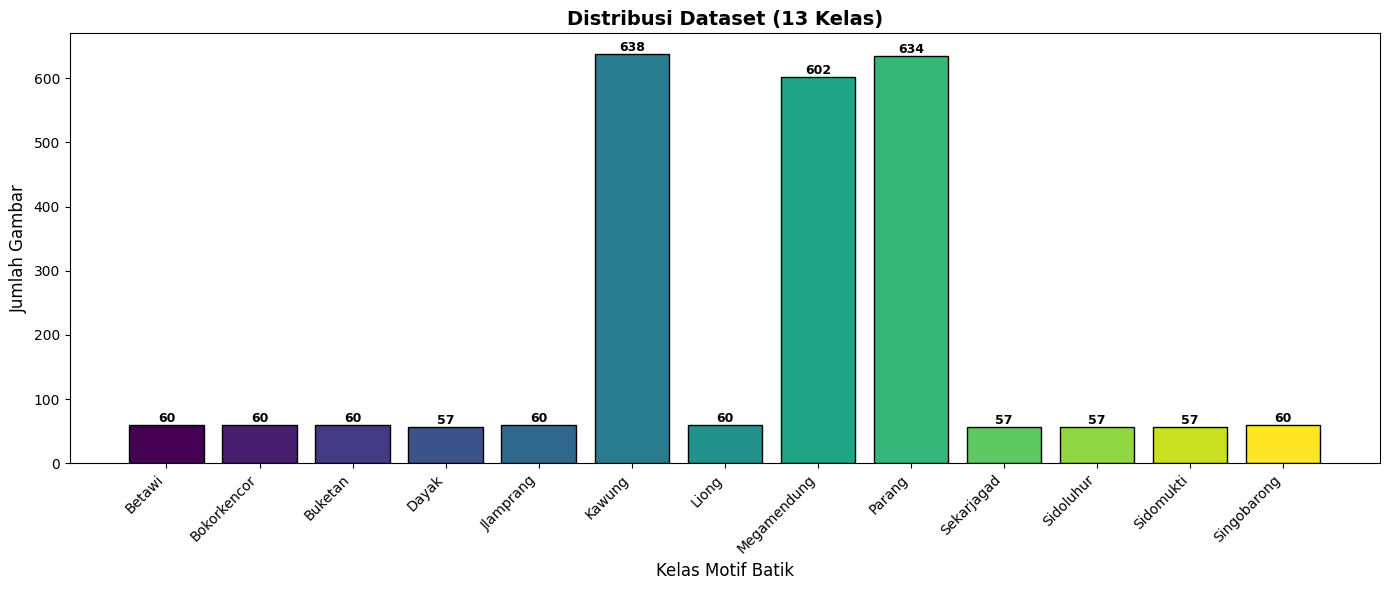

2026-01-13 17:05:52,517 - INFO - ✓ Visualisasi distribusi disimpan: 00_dataset_distribution.png


In [4]:
# Visualisasi distribusi dataset
plt.figure(figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 1, NUM_CLASSES))
bars = plt.bar(CLASS_NAMES, class_dist.values(), color=colors, edgecolor='black')

for bar, count in zip(bars, class_dist.values()):
    plt.text(bar.get_x() + bar.get_width()/2, count, f'{count}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Kelas Motif Batik', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.title(f'Distribusi Dataset ({NUM_CLASSES} Kelas)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('00_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

logger.info("✓ Visualisasi distribusi disimpan: 00_dataset_distribution.png")

In [5]:
print(f"\n📊 Split Dataset Awal")
X_trainval_pool, X_test, y_trainval_pool, y_test = train_test_split(
    all_paths, all_labels, 
    test_size=TEST_SIZE, 
    stratify=all_labels, 
    random_state=SEED
)

print(f"\n✓ Split Awal:")
print(f"  • Train+Val Pool: {len(X_trainval_pool)} gambar ({len(X_trainval_pool)/len(all_paths)*100:.1f}%)")
print(f"  • Test Set (LOCKED): {len(X_test)} gambar ({len(X_test)/len(all_paths)*100:.1f}%)")



📊 Split Dataset Awal

✓ Split Awal:
  • Train+Val Pool: 2092 gambar (85.0%)
  • Test Set (LOCKED): 370 gambar (15.0%)


In [6]:
# Distribusi test set
test_dist = Counter(y_test)
print(f"\n  Distribusi Test Set:")
for i in range(NUM_CLASSES):
    print(f"    {CLASS_NAMES[i]}: {test_dist[i]} gambar")

# Save test set info
test_set_info = {
    'test_paths': X_test.tolist(),
    'test_labels': y_test.tolist(),
    'class_names': CLASS_NAMES
}
with open('test_set_info.json', 'w') as f:
    json.dump(test_set_info, f)

logger.info("✓ Test set info disimpan: test_set_info.json")

2026-01-13 17:05:52,563 - INFO - ✓ Test set info disimpan: test_set_info.json



  Distribusi Test Set:
    Betawi: 9 gambar
    Bokorkencor: 9 gambar
    Buketan: 9 gambar
    Dayak: 9 gambar
    Jlamprang: 9 gambar
    Kawung: 96 gambar
    Liong: 9 gambar
    Megamendung: 90 gambar
    Parang: 95 gambar
    Sekarjagad: 8 gambar
    Sidoluhur: 9 gambar
    Sidomukti: 9 gambar
    Singobarong: 9 gambar


In [7]:
# Augmentation untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Hanya normalisasi untuk validation
val_datagen = ImageDataGenerator(
    rescale=1./255,
)

logger.info("✓ Data preprocessing telah dibuat")
logger.info("  • Training: Augmentation ON (rotation, shift, zoom, flip, brightness)")
logger.info("  • Validation/Test: Augmentation OFF")

2026-01-13 17:05:52,584 - INFO - ✓ Data preprocessing telah dibuat
2026-01-13 17:05:52,585 - INFO -   • Training: Augmentation ON (rotation, shift, zoom, flip, brightness)
2026-01-13 17:05:52,587 - INFO -   • Validation/Test: Augmentation OFF


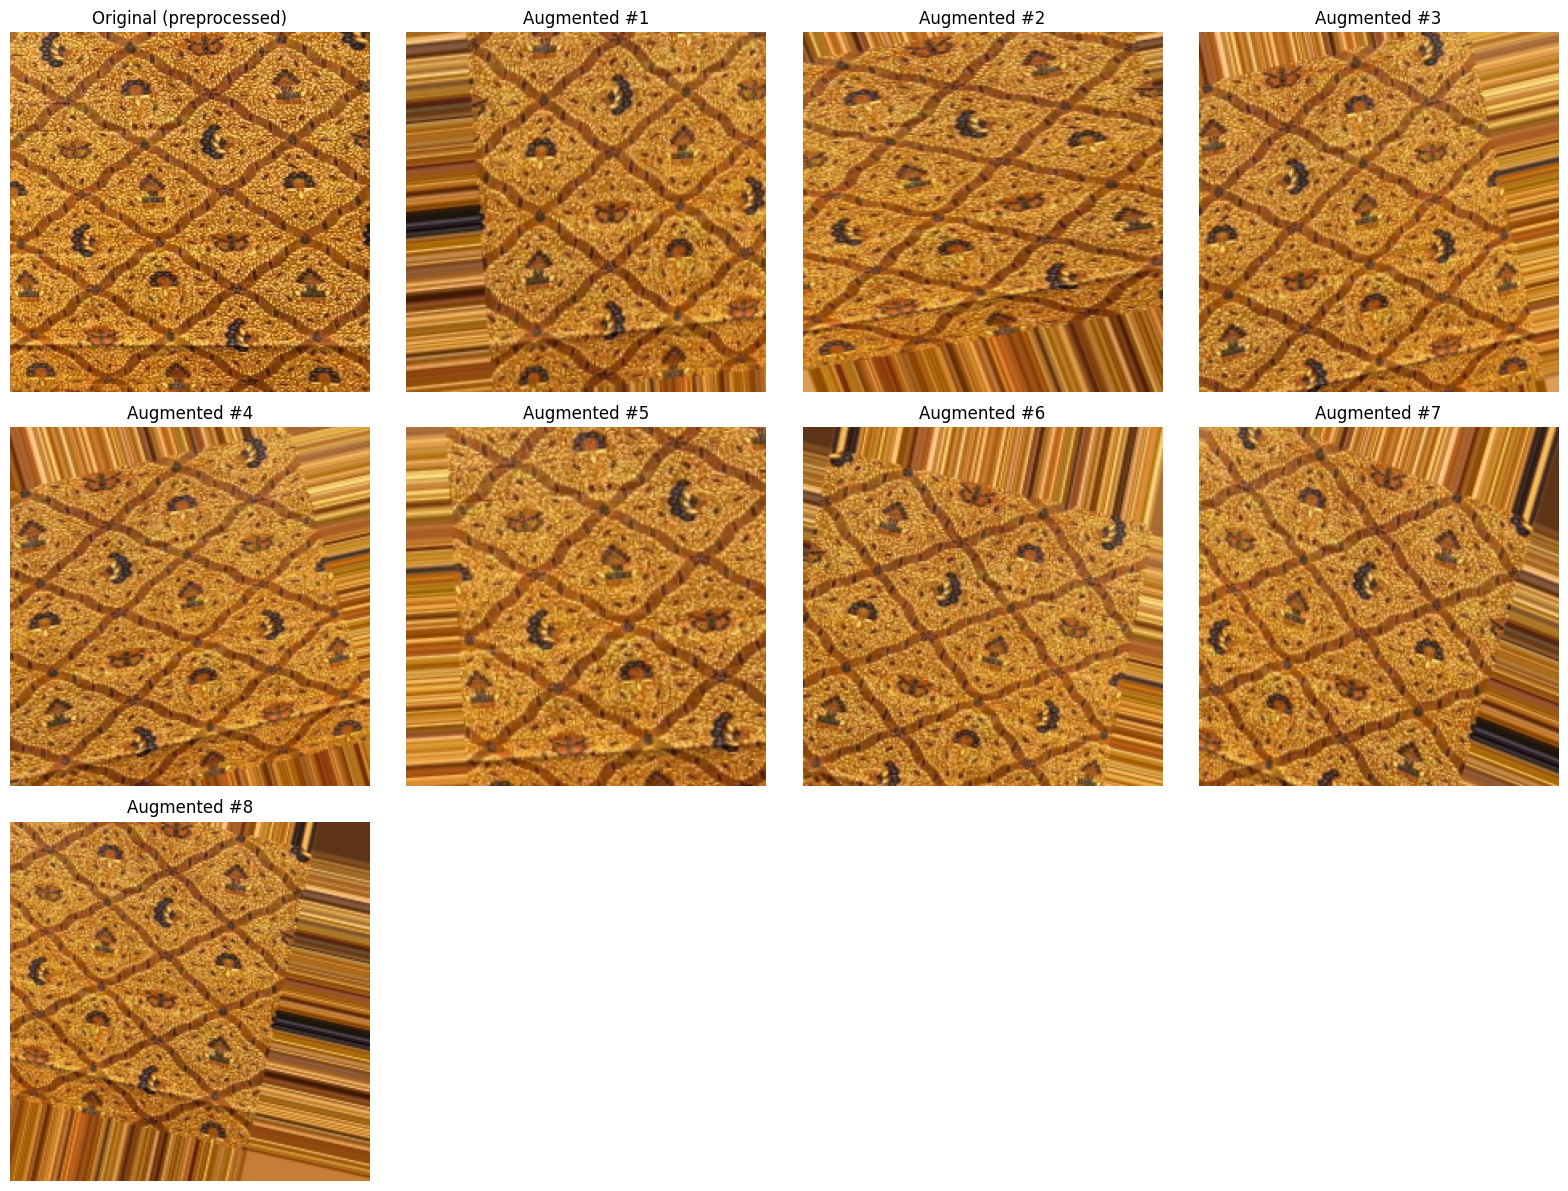

2026-01-13 17:05:54,775 - INFO - ✓ Visualisasi augmentasi disimpan: 01_augmentation_visualization.png


In [8]:
def visualize_augmentation(sample_path, datagen, n_aug=8, title_prefix="Augmented"):
    # Load original image
    img = tf.keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
    if img.mode != "RGB":
        img = img.convert("RGB")
    img_arr = tf.keras.utils.img_to_array(img)

    # Prepare augmented samples
    augmented = []
    for _ in range(n_aug):
        x = img_arr.copy()
        x = datagen.random_transform(x)   # apply augmentation transforms
        x = datagen.standardize(x)        # apply rescale (and preprocessing if any)
        augmented.append(x)

    # Plot
    n_cols = 4
    n_rows = int(np.ceil((n_aug + 1) / n_cols))
    plt.figure(figsize=(4*n_cols, 4*n_rows))

    # Original (apply ONLY standardize from val_datagen to show “preprocessed original”)
    x0 = val_datagen.standardize(img_arr.copy())
    plt.subplot(n_rows, n_cols, 1)
    plt.imshow(np.clip(x0, 0, 1))
    plt.title("Original (preprocessed)")
    plt.axis("off")

    # Augmented versions
    for i, x in enumerate(augmented, start=2):
        plt.subplot(n_rows, n_cols, i)
        plt.imshow(np.clip(x, 0, 1))
        plt.title(f"{title_prefix} #{i-1}")
        plt.axis("off")

    plt.tight_layout()
    out_path = "01_augmentation_visualization.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    logger.info(f"✓ Visualisasi augmentasi disimpan: {out_path}")

# contoh pemanggilan (ambil 1 contoh dari trainval pool)
visualize_augmentation(X_trainval_pool[0], train_datagen, n_aug=8)

In [9]:
def build_model(dropout_rate=0.3):
    """Build MobileNetV2 model"""
    base_model = MobileNetV2(
        input_shape=IMAGE_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    
    inputs = Input(shape=IMAGE_SIZE + (3,), name="input_layer")
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D(name="global_avg_pooling")(x)
    x = BatchNormalization(name="batch_norm")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name="output_layer")(x)
    
    model = Model(inputs, outputs, name='MobileNetV2_Batik_13Class')
    return model, base_model

In [10]:
def load_batch_data(X, y, batch_size, datagen):
    """Generator untuk load data dalam batch"""
    indices = np.arange(len(X))
    while True:
        np.random.shuffle(indices)
        for start in range(0, len(X), batch_size):
            end = min(start + batch_size, len(X))
            batch_indices = indices[start:end]
            
            batch_images = []
            batch_labels = []
            
            for idx in batch_indices:
                try:
                    img = tf.keras.utils.load_img(X[idx], target_size=IMAGE_SIZE)
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    img_array = tf.keras.utils.img_to_array(img)
                    img_array = datagen.standardize(img_array)
                    batch_images.append(img_array)
                    batch_labels.append(y[idx])
                except:
                    continue
            
            if len(batch_images) > 0:
                yield np.array(batch_images), tf.keras.utils.to_categorical(batch_labels, NUM_CLASSES)

logger.info("✓ Fungsi build_model() dan load_batch_data() telah dibuat")

2026-01-13 17:06:33,170 - INFO - ✓ Fungsi build_model() dan load_batch_data() telah dibuat


In [11]:
from sklearn.model_selection import ParameterGrid

def grid_search_tuning(optimizer_name, X_train, y_train, X_val, y_val, iteration):
    """Grid Search"""
    logger.info(f"\n[Iter {iteration}] Grid Search - {optimizer_name}")
    
    param_grid = list(ParameterGrid(HYPERPARAMETER_SPACE))
    best_score = 0
    best_params = None
    
    for params in tqdm(param_grid, desc=f"Grid Search {optimizer_name}"):
        model, base_model = build_model(dropout_rate=params['dropout_rate'])
        
        if optimizer_name == 'Adam':
            opt = Adam(learning_rate=params['learning_rate'])
        elif optimizer_name == 'SGD':
            opt = SGD(learning_rate=params['learning_rate'], momentum=0.9, nesterov=True)
        elif optimizer_name == 'RMSprop':
            opt = RMSprop(learning_rate=params['learning_rate'])
        elif optimizer_name == 'Adagrad':
            opt = Adagrad(learning_rate=params['learning_rate'])
        
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
        
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=2,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=0
        )
        
        steps = len(X_train) // params['batch_size']
        val_steps = len(X_val) // params['batch_size']
        
        history = model.fit(
            load_batch_data(X_train, y_train, params['batch_size'], train_datagen),
            steps_per_epoch=steps,
            validation_data=load_batch_data(X_val, y_val, params['batch_size'], val_datagen),
            validation_steps=val_steps,
            epochs=TUNING_EPOCHS,
            callbacks=[early_stop],
            verbose=0
        )
        
        val_acc = max(history.history['val_accuracy'])
        
        if val_acc > best_score:
            best_score = val_acc
            best_params = params
        
        del model, base_model, history
        tf.keras.backend.clear_session()
    
    logger.info(f"✓ Best Params: {best_params}, Val Acc: {best_score:.4f}")
    return best_params, best_score

In [12]:
def random_search_tuning(optimizer_name, X_train, y_train, X_val, y_val, iteration, n_trials=6):
    """Random Search"""
    logger.info(f"\n[Iter {iteration}] Random Search - {optimizer_name}")
    
    best_score = 0
    best_params = None
    
    for trial in tqdm(range(n_trials), desc=f"Random Search {optimizer_name}"):
        params = {
            'learning_rate': np.random.choice(HYPERPARAMETER_SPACE['learning_rate']),
            'batch_size': np.random.choice(HYPERPARAMETER_SPACE['batch_size']),
            'dropout_rate': np.random.choice(HYPERPARAMETER_SPACE['dropout_rate'])
        }
        
        model, base_model = build_model(dropout_rate=params['dropout_rate'])
        
        if optimizer_name == 'Adam':
            opt = Adam(learning_rate=params['learning_rate'])
        elif optimizer_name == 'SGD':
            opt = SGD(learning_rate=params['learning_rate'], momentum=0.9, nesterov=True)
        elif optimizer_name == 'RMSprop':
            opt = RMSprop(learning_rate=params['learning_rate'])
        elif optimizer_name == 'Adagrad':
            opt = Adagrad(learning_rate=params['learning_rate'])
        
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
        
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=2,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=0
        )
        
        steps = len(X_train) // params['batch_size']
        val_steps = len(X_val) // params['batch_size']
        
        history = model.fit(
            load_batch_data(X_train, y_train, params['batch_size'], train_datagen),
            steps_per_epoch=steps,
            validation_data=load_batch_data(X_val, y_val, params['batch_size'], val_datagen),
            validation_steps=val_steps,
            epochs=TUNING_EPOCHS,
            callbacks=[early_stop],
            verbose=0
        )
        
        val_acc = max(history.history['val_accuracy'])
        
        if val_acc > best_score:
            best_score = val_acc
            best_params = params
        
        del model, base_model, history
        tf.keras.backend.clear_session()
    
    logger.info(f"✓ Best Params: {best_params}, Val Acc: {best_score:.4f}")
    return best_params, best_score

In [13]:
def bayesian_optimization_tuning(optimizer_name, X_train, y_train, X_val, y_val, iteration, max_trials=6):
    """Bayesian Optimization"""
    logger.info(f"\n[Iter {iteration}] Bayesian Opt - {optimizer_name}")
    
    import keras_tuner as kt
    import logging as kt_logging
    kt_logging.getLogger("tensorflow").setLevel(kt_logging.ERROR)
    kt_logging.getLogger("keras_tuner").setLevel(kt_logging.WARNING)
    
    def build_tuning_model(hp):
        lr = hp.Choice('learning_rate', HYPERPARAMETER_SPACE['learning_rate'])
        batch = hp.Choice('batch_size', HYPERPARAMETER_SPACE['batch_size'])
        dropout = hp.Choice('dropout_rate', HYPERPARAMETER_SPACE['dropout_rate'])
        
        model, _ = build_model(dropout_rate=dropout)
        
        if optimizer_name == 'Adam':
            opt = Adam(learning_rate=lr)
        elif optimizer_name == 'SGD':
            opt = SGD(learning_rate=lr, momentum=0.9, nesterov=True)
        elif optimizer_name == 'RMSprop':
            opt = RMSprop(learning_rate=lr)
        elif optimizer_name == 'Adagrad':
            opt = Adagrad(learning_rate=lr)
        
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
        return model
    
    tuner = kt.BayesianOptimization(
        build_tuning_model,
        objective='val_accuracy',
        max_trials=max_trials,
        directory='tuning_logs',
        project_name=f'bayesian_{optimizer_name}_iter{iteration}',
        overwrite=True
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=0
    )
    
    steps = len(X_train) // BATCH_SIZE
    val_steps = len(X_val) // BATCH_SIZE
    
    tuner.search(
        load_batch_data(X_train, y_train, BATCH_SIZE, train_datagen),
        steps_per_epoch=steps,
        validation_data=load_batch_data(X_val, y_val, BATCH_SIZE, val_datagen),
        validation_steps=val_steps,
        epochs=TUNING_EPOCHS,
        callbacks=[early_stop],
        verbose=0
    )
    
    best_hps = tuner.get_best_hyperparameters(1)[0]
    best_params = {
        'learning_rate': best_hps.get('learning_rate'),
        'batch_size': best_hps.get('batch_size'),
        'dropout_rate': best_hps.get('dropout_rate')
    }
    
    best_model = tuner.get_best_models(1)[0]
    val_loss, val_acc = best_model.evaluate(
        load_batch_data(X_val, y_val, best_params['batch_size'], val_datagen),
        steps=len(X_val) // best_params['batch_size'],
        verbose=0
    )
    
    logger.info(f"✓ Best Params: {best_params}, Val Acc: {val_acc:.4f}")
    
    del best_model
    tf.keras.backend.clear_session()
    
    return best_params, val_acc

In [14]:
def pso_tuning(optimizer_name, X_train, y_train, X_val, y_val, iteration, n_particles=4, n_iterations=4):
    """PSO"""
    logger.info(f"\n[Iter {iteration}] PSO - {optimizer_name}")
    
    import pyswarms as ps
    
    lr_options = HYPERPARAMETER_SPACE['learning_rate']
    batch_options = HYPERPARAMETER_SPACE['batch_size']
    dropout_options = HYPERPARAMETER_SPACE['dropout_rate']
    
    bounds = (np.array([0, 0, 0]), 
              np.array([len(lr_options)-1, len(batch_options)-1, len(dropout_options)-1]))
    
    def objective_function(particles):
        costs = []
        for position in particles:
            lr_idx = int(np.clip(np.round(position[0]), 0, len(lr_options)-1))
            batch_idx = int(np.clip(np.round(position[1]), 0, len(batch_options)-1))
            dropout_idx = int(np.clip(np.round(position[2]), 0, len(dropout_options)-1))
            
            params = {
                'learning_rate': lr_options[lr_idx],
                'batch_size': batch_options[batch_idx],
                'dropout_rate': dropout_options[dropout_idx]
            }
            
            model, base_model = build_model(dropout_rate=params['dropout_rate'])
            
            if optimizer_name == 'Adam':
                opt = Adam(learning_rate=params['learning_rate'])
            elif optimizer_name == 'SGD':
                opt = SGD(learning_rate=params['learning_rate'], momentum=0.9, nesterov=True)
            elif optimizer_name == 'RMSprop':
                opt = RMSprop(learning_rate=params['learning_rate'])
            elif optimizer_name == 'Adagrad':
                opt = Adagrad(learning_rate=params['learning_rate'])
            
            model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
            
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=2,
                min_delta=0.001,
                restore_best_weights=True,
                verbose=0
            )
            
            steps = len(X_train) // params['batch_size']
            val_steps = len(X_val) // params['batch_size']
            
            history = model.fit(
                load_batch_data(X_train, y_train, params['batch_size'], train_datagen),
                steps_per_epoch=steps,
                validation_data=load_batch_data(X_val, y_val, params['batch_size'], val_datagen),
                validation_steps=val_steps,
                epochs=TUNING_EPOCHS,
                callbacks=[early_stop],
                verbose=0
            )
            
            val_acc = max(history.history['val_accuracy'])
            cost = 1 - val_acc
            costs.append(cost)
            
            del model, base_model, history
            tf.keras.backend.clear_session()
        
        return np.array(costs)
    
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
    optimizer_pso = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=3,
        options=options,
        bounds=bounds
    )
    
    cost, pos = optimizer_pso.optimize(objective_function, iters=n_iterations, verbose=False)
    
    lr_idx = int(np.clip(np.round(pos[0]), 0, len(lr_options)-1))
    batch_idx = int(np.clip(np.round(pos[1]), 0, len(batch_options)-1))
    dropout_idx = int(np.clip(np.round(pos[2]), 0, len(dropout_options)-1))
    
    best_params = {
        'learning_rate': lr_options[lr_idx],
        'batch_size': batch_options[batch_idx],
        'dropout_rate': dropout_options[dropout_idx]
    }
    best_score = 1 - cost
    
    logger.info(f"✓ Best Params: {best_params}, Val Acc: {best_score:.4f}")
    
    return best_params, best_score

In [15]:
def get_optimizer(optimizer_name, learning_rate):
    if optimizer_name == 'Adam':
        return Adam(learning_rate=learning_rate)
    if optimizer_name == 'SGD':
        return SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)
    if optimizer_name == 'RMSprop':
        return RMSprop(learning_rate=learning_rate)
    if optimizer_name == 'Adagrad':
        return Adagrad(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")

In [16]:
def freeze_batchnorm_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

In [17]:
def two_phase_training(optimizer_name, best_params, X_train, y_train, X_val, y_val, iteration, experiment_name):
    """
    Two-phase training:
    Phase 1: transfer learning (base frozen)
    Phase 2: fine-tuning (unfreeze top layers)
    Returns: model, history_dict, training_time_sec, best_val_acc, best_val_loss, total_epochs_run
    """
    logger.info(f"\n[Iter {iteration}] TRAINING: {experiment_name}")
    logger.info(f"Params: {best_params}")

    model, base_model = build_model(dropout_rate=best_params['dropout_rate'])

    # -------- Phase 1 --------
    logger.info(f"[Iter {iteration}] Phase 1: Transfer Learning")
    base_model.trainable = False

    opt1 = get_optimizer(optimizer_name, best_params['learning_rate'])
    model.compile(optimizer=opt1, loss='categorical_crossentropy', metrics=['accuracy'])

    es1 = EarlyStopping(
        monitor='val_loss',
        patience=PHASE1_PATIENCE,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=0
    )

    bs = int(best_params['batch_size'])
    steps = max(1, len(X_train) // bs)
    val_steps = max(1, len(X_val) // bs)

    start = time.time()
    h1 = model.fit(
        load_batch_data(X_train, y_train, bs, train_datagen),
        steps_per_epoch=steps,
        validation_data=load_batch_data(X_val, y_val, bs, val_datagen),
        validation_steps=val_steps,
        epochs=PHASE1_MAX_EPOCHS,
        callbacks=[es1],
        verbose=0
    )
    t1 = time.time() - start

    # -------- Phase 2 --------
    logger.info(f"[Iter {iteration}] Phase 2: Fine-tuning")
    base_model.trainable = True

    # unfreeze only last N layers of base model
    UNFREEZE_LAST_N = 30
    for layer in base_model.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False

    # freeze BN layers for stability (recommended for smaller datasets)
    freeze_batchnorm_layers(model)

    fine_lr = best_params['learning_rate'] / 10.0
    opt2 = get_optimizer(optimizer_name, fine_lr)
    model.compile(optimizer=opt2, loss='categorical_crossentropy', metrics=['accuracy'])

    es2 = EarlyStopping(
        monitor='val_loss',
        patience=PHASE2_PATIENCE,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=0
    )

    start = time.time()
    h2 = model.fit(
        load_batch_data(X_train, y_train, bs, train_datagen),
        steps_per_epoch=steps,
        validation_data=load_batch_data(X_val, y_val, bs, val_datagen),
        validation_steps=val_steps,
        epochs=PHASE2_MAX_EPOCHS,
        callbacks=[es2],
        verbose=0
    )
    t2 = time.time() - start

    # merge history
    history = {
        'accuracy': h1.history.get('accuracy', []) + h2.history.get('accuracy', []),
        'val_accuracy': h1.history.get('val_accuracy', []) + h2.history.get('val_accuracy', []),
        'loss': h1.history.get('loss', []) + h2.history.get('loss', []),
        'val_loss': h1.history.get('val_loss', []) + h2.history.get('val_loss', []),
    }

    total_time = t1 + t2
    total_epochs_run = len(history['val_loss'])

    best_val_acc = float(np.max(history['val_accuracy'])) if len(history['val_accuracy']) else np.nan
    best_val_loss = float(np.min(history['val_loss'])) if len(history['val_loss']) else np.nan

    logger.info(f"[Iter {iteration}] Done. Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}, Time: {total_time/60:.2f} min, Epochs: {total_epochs_run}")
    return model, history, total_time, best_val_acc, best_val_loss, total_epochs_run

In [18]:
def stratified_sample(X, y, sampling_size, seed):
    """Stratified sampling from a pool."""
    sss = StratifiedShuffleSplit(n_splits=1, train_size=sampling_size, random_state=seed)
    idx_train, idx_rest = next(sss.split(X, y))
    return X[idx_train], y[idx_train], X[idx_rest], y[idx_rest]

In [19]:
def evaluate_on_test(model, X_test, y_test, batch_size):
    """Evaluate on locked test set and return y_true, y_pred."""
    test_steps = max(1, len(X_test) // batch_size)
    test_gen = load_batch_data(X_test, y_test, batch_size, val_datagen)

    y_true = []
    y_pred = []

    for _ in tqdm(range(test_steps), desc="Testing"):
        x_batch, y_batch = next(test_gen)
        probs = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(probs, axis=1))

    return np.array(y_true), np.array(y_pred)

In [20]:
all_loop_results = []
best_models_summary = []  # best per iteration

VAL_SPLIT_IN_ITER = 0.2  # within sampled data

for iteration in range(1, N_ITERATIONS + 1):
    logger.info(f"\n{'='*90}\nITERATION {iteration}/{N_ITERATIONS}\n{'='*90}")

    # 1) sample from train+val pool
    X_sample, y_sample, X_rest, y_rest = stratified_sample(
        X_trainval_pool, y_trainval_pool, sampling_size=SAMPLING_SIZE, seed=SEED + iteration
    )

    # 2) split sample into train_i / val_i
    X_train_i, X_val_i, y_train_i, y_val_i = train_test_split(
        X_sample, y_sample,
        test_size=VAL_SPLIT_IN_ITER,
        stratify=y_sample,
        random_state=SEED + 1000 + iteration
    )

    logger.info(f"[Iter {iteration}] Sample size: {len(X_sample)} | Train_i: {len(X_train_i)} | Val_i: {len(X_val_i)}")

    # record distribution
    dist_train = Counter(y_train_i)
    dist_val = Counter(y_val_i)
    logger.info(f"[Iter {iteration}] Train_i distribution: " + ", ".join([f"{CLASS_NAMES[k]}={dist_train[k]}" for k in range(NUM_CLASSES)]))
    logger.info(f"[Iter {iteration}] Val_i distribution: " + ", ".join([f"{CLASS_NAMES[k]}={dist_val[k]}" for k in range(NUM_CLASSES)]))

    iteration_results = []
    best_iter_entry = None

    for optimizer_name in OPTIMIZERS:
        for tuning_method in TUNING_METHODS:
            experiment_name = f"Iter{iteration}_{optimizer_name}_{tuning_method.replace(' ', '_')}"
            logger.info(f"\n[Iter {iteration}] EXPERIMENT: {experiment_name}")

            try:
                # 3) tuning step
                if tuning_method == 'Grid Search':
                    best_params, tuning_score = grid_search_tuning(
                        optimizer_name, X_train_i, y_train_i, X_val_i, y_val_i, iteration
                    )

                elif tuning_method == 'Random Search':
                    best_params, tuning_score = random_search_tuning(
                        optimizer_name, X_train_i, y_train_i, X_val_i, y_val_i, iteration,
                        n_trials=TUNING_CONFIG['random_search']
                    )

                elif tuning_method == 'Bayesian Optimization':
                    best_params, tuning_score = bayesian_optimization_tuning(
                        optimizer_name, X_train_i, y_train_i, X_val_i, y_val_i, iteration,
                        max_trials=TUNING_CONFIG['bayesian_optimization']
                    )

                elif tuning_method == 'PSO':
                    best_params, tuning_score = pso_tuning(
                        optimizer_name, X_train_i, y_train_i, X_val_i, y_val_i, iteration,
                        n_particles=TUNING_CONFIG['pso']['n_particles'],
                        n_iterations=TUNING_CONFIG['pso']['n_iterations']
                    )
                else:
                    raise ValueError(f"Unknown tuning method: {tuning_method}")

                # 4) train best config with two-phase training
                model, history, train_time, best_val_acc, best_val_loss, epochs_run = two_phase_training(
                    optimizer_name, best_params,
                    X_train_i, y_train_i, X_val_i, y_val_i,
                    iteration, experiment_name
                )

                # 5) evaluate on validation (single pass)
                bs = int(best_params['batch_size'])
                val_steps = max(1, len(X_val_i) // bs)
                val_loss, val_acc = model.evaluate(
                    load_batch_data(X_val_i, y_val_i, bs, val_datagen),
                    steps=val_steps,
                    verbose=0
                )

                result_entry = {
                    'Iteration': iteration,
                    'Experiment': experiment_name,
                    'Optimizer': optimizer_name,
                    'Tuning Method': tuning_method,
                    'Learning Rate': float(best_params['learning_rate']),
                    'Batch Size': int(best_params['batch_size']),
                    'Dropout Rate': float(best_params['dropout_rate']),
                    'Tuning Score (val_acc)': float(tuning_score) if tuning_score is not None else np.nan,
                    'Val Accuracy (eval)': float(val_acc),
                    'Val Loss (eval)': float(val_loss),
                    'Best Val Accuracy (history)': float(best_val_acc),
                    'Best Val Loss (history)': float(best_val_loss),
                    'Epochs Run': int(epochs_run),
                    'Training Time (s)': float(train_time),
                    'Training Time (min)': float(train_time / 60.0),
                }

                iteration_results.append(result_entry)
                all_loop_results.append(result_entry)

                # select best per iteration by Val Accuracy (eval)
                if (best_iter_entry is None) or (result_entry['Val Accuracy (eval)'] > best_iter_entry['Val Accuracy (eval)']):
                    best_iter_entry = result_entry.copy()

                    # save best model of this iteration
                    os.makedirs("models_per_iter", exist_ok=True)
                    best_model_path = f"models_per_iter/best_iter{iteration}.keras"
                    model.save(best_model_path)
                    best_iter_entry['Saved Model Path'] = best_model_path

                # cleanup
                del model, history
                tf.keras.backend.clear_session()

                logger.info(f"[Iter {iteration}] OK: val_acc={val_acc:.4f}, val_loss={val_loss:.4f}")

            except Exception as e:
                logger.exception(f"[Iter {iteration}] ERROR in {experiment_name}: {str(e)}")
                tf.keras.backend.clear_session()
                continue

    # save iteration results
    iter_df = pd.DataFrame(iteration_results)
    iter_df.to_csv(f"results_iteration_{iteration}.csv", index=False)
    logger.info(f"[Iter {iteration}] Results saved: results_iteration_{iteration}.csv")

    if best_iter_entry is not None:
        best_models_summary.append(best_iter_entry)

2026-01-13 17:06:33,392 - INFO - 
ITERATION 1/5
2026-01-13 17:06:33,408 - INFO - [Iter 1] Sample size: 1569 | Train_i: 1255 | Val_i: 314
2026-01-13 17:06:33,408 - INFO - [Iter 1] Train_i distribution: Betawi=30, Bokorkencor=30, Buketan=30, Dayak=29, Jlamprang=31, Kawung=326, Liong=31, Megamendung=307, Parang=323, Sekarjagad=30, Sidoluhur=29, Sidomukti=29, Singobarong=30
2026-01-13 17:06:33,409 - INFO - [Iter 1] Val_i distribution: Betawi=8, Bokorkencor=8, Buketan=8, Dayak=7, Jlamprang=8, Kawung=81, Liong=7, Megamendung=77, Parang=81, Sekarjagad=7, Sidoluhur=7, Sidomukti=7, Singobarong=8
2026-01-13 17:06:33,411 - INFO - 
[Iter 1] EXPERIMENT: Iter1_Adam_Grid_Search
2026-01-13 17:06:33,412 - INFO - 
[Iter 1] Grid Search - Adam
Grid Search Adam: 100%|██████████| 12/12 [07:45<00:00, 38.80s/it]
2026-01-13 17:14:19,067 - INFO - ✓ Best Params: {'batch_size': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001}, Val Acc: 0.8684
2026-01-13 17:14:19,070 - INFO - 
[Iter 1] TRAINING: Iter1_Adam_Grid_Se

In [34]:
import shutil
import os

OUTPUT_TEST_DIR = "exported_test_set"
os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

for img_path, label in zip(X_test, y_test):
    class_name = CLASS_NAMES[label]
    class_dir = os.path.join(OUTPUT_TEST_DIR, class_name)
    os.makedirs(class_dir, exist_ok=True)

    filename = os.path.basename(img_path)
    dst_path = os.path.join(class_dir, filename)

    # copy file (bukan move)
    shutil.copy(img_path, dst_path)

print(f"✓ Test set berhasil diekspor ke folder: {OUTPUT_TEST_DIR}")


✓ Test set berhasil diekspor ke folder: exported_test_set


In [32]:
# Load hasil keseluruhan
df = pd.read_csv("all_loop_results.csv")  # atau sesuaikan path-nya

# Opsi tampilan biar rapi
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 50)

rank_cols = [
    "Iteration", "Optimizer", "Tuning Method",
    "Learning Rate", "Batch Size", "Dropout Rate",
    "Val Accuracy (eval)", "Val Loss (eval)",
    "Epochs Run", "Training Time (min)"
]

df_rank = df.sort_values("Val Accuracy (eval)", ascending=False).reset_index(drop=True)
df_rank.insert(0, "Rank", range(1, len(df_rank) + 1))

display(df_rank[rank_cols + ["Rank"]].sort_values("Rank"))

,Iteration,Optimizer,Tuning Method,Learning Rate,Batch Size,Dropout Rate,Val Accuracy (eval),Val Loss (eval),Epochs Run,Training Time (min),Rank
0,5,Adagrad,PSO,0.010,16,0.2,0.953947,0.256217,27,4.007136,1
1,2,Adagrad,Grid Search,0.010,16,0.2,0.937500,0.294636,24,3.656083,2
2,4,RMSprop,Grid Search,0.001,16,0.5,0.937500,0.323486,22,3.222995,3
3,2,RMSprop,Random Search,0.001,16,0.5,0.934211,0.271710,22,3.352705,4
4,5,RMSprop,PSO,0.001,32,0.5,0.934028,0.272230,24,3.326454,5
...,...,...,...,...,...,...,...,...,...,...,...
75,1,SGD,Random Search,0.010,16,0.2,0.250000,2.139896,15,2.099132,76
76,2,SGD,PSO,0.010,32,0.3,0.246528,1.987440,19,2.779706,77
77,4,SGD,Grid Search,0.010,32,0.2,0.236111,2.009275,19,2.677516,78
78,2,SGD,Random Search,0.010,32,0.3,0.236111,1.995417,15,2.024259,79


In [33]:
metrics = ["Val Accuracy (eval)", "Val Loss (eval)", "Epochs Run", "Training Time (min)"]

summary = (
    df.groupby(["Optimizer", "Tuning Method"])[metrics]
      .agg(["mean", "std", "count"])
      .reset_index()
)

display(summary)

Optimizer          Tuning Method Val Accuracy (eval)                 Val Loss (eval)                  Epochs Run                 Training Time (min)                
                                                   mean       std count            mean        std count       mean       std count                mean       std count
0    Adagrad  Bayesian Optimization            0.906908  0.022178     5        0.338942   0.052898     5       26.4  5.272571     5            3.795079  0.837868     5
1    Adagrad            Grid Search            0.903618  0.034649     5        0.349029   0.104160     5       22.4  4.505552     5            3.368088  0.795507     5
2    Adagrad                    PSO            0.913414  0.034900     5        0.335775   0.070975     5       24.2  5.805170     5            3.464664  0.854939     5
3    Adagrad          Random Search            0.903289  0.017957     5        0.339598   0.047383     5       25.4  4.722288     5            3.640449  0.680278     5
4       Adam  Bayesian Optimization            0.903582  0.013876     5        0.391088   0.062691     5       24.0  1.224745     5            3.314635  0.251614     5
5       Adam            Grid Search            0.905665  0.015771     5        0.377294   0.085754     5       23.6  4.827007     5            3.319687  0.710739     5
6       Adam                    PSO            0.897588  0.030049     5        0.401443   0.076068     5       19.6  4.827007     5            2.752384  0.667188     5
7       Adam          Random Search            0.791740  0.270078     5        0.681553   0.738930     5       17.4  4.277850     5            2.481383  0.583569     5
8    RMSprop  Bayesian Optimization            0.898319  0.027178     5        0.391355   0.061117     5       18.8  3.420526     5            2.790080  0.496224     5
9    RMSprop            Grid Search            0.767069  0.286597     5        0.837099   0.961706     5       18.8  3.701351     5            2.757815  0.546361     5
10   RMSprop                    PSO            0.913341  0.014419     5        0.359594   0.060834     5       22.0  4.242641     5            3.218684  0.666236     5
11   RMSprop          Random Search            0.899927  0.027532     5        0.352128   0.093461     5       19.2  4.086563     5            2.812115  0.549381     5
12       SGD  Bayesian Optimization            0.651754  0.359089     5        1.467679   1.744044     5       24.2  5.761944     5            3.434805  0.810554     5
13       SGD            Grid Search            0.209430  0.103229     5        8.053314  13.620592     5       17.8  5.069517     5            2.490344  0.727680     5
14       SGD                    PSO            0.264583  0.025207     5        1.955233   0.020189     5       17.4  2.701851     5            2.441493  0.408903     5
15       SGD          Random Search            0.377522  0.281983     5        1.701829   0.713690     5       16.4  4.098780     5            2.333735  0.592242     5